# PatchTST - Patch-based Transformer for RUL Prediction

Unlike LSTM and TCN models that process each time series data point recurrently or convolutively, PatchTST adopts an entirely different technique from the Vision Transformer that divides the time series into **non-overlapping patches**, which are then treated as tokens.

Why use patches rather than individual time steps? 
- Individual cycles of the sensor measurements are very noisy as shown by the results of the exploratory analysis. Patching reduces noise naturally by averaging across several cycles, even before the attention module works.
- Self-attention in a transformer model over 30 consecutive time steps would be computationally expensive, not to mention that the sequence is already too short for attention to work well. Patching helps in reducing the sequence length while keeping the temporal aspect intact.
- Each patch represents a local temporal pattern (a portion of the degradation path), and attention later figures out how significant each of the patches is for making predictions.

For a sequence length of 30 cycles and patches of 5 time steps each, the result is six tokens, which is a good number for attention to work on effectively without waste.

##### Ref--->https://arxiv.org/abs/2211.14730

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import math
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

with open('../checkpoints/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('../checkpoints/feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

RUL_CLIP    = 125
WINDOW_SIZE = 30

col_names = ['unit', 'cycle', 'os1', 'os2', 'os3'] + [f's{i}' for i in range(1, 22)]

train_raw = pd.read_csv('../data/raw/train_FD001.txt', sep='\s+', header=None, names=col_names)
test_raw  = pd.read_csv('../data/raw/test_FD001.txt',  sep='\s+', header=None, names=col_names)
rul_test  = pd.read_csv('../data/raw/RUL_FD001.txt',   header=None, names=['rul'])

print("loaded. features:", len(feature_cols), "| window:", WINDOW_SIZE)

loaded. features: 14 | window: 30


In [2]:
def add_rul(df):
    max_cycles = df.groupby('unit')['cycle'].max()
    df = df.merge(max_cycles.rename('max_cycle'), on='unit')
    df['rul'] = (df['max_cycle'] - df['cycle']).clip(upper=RUL_CLIP)
    return df

def make_windows(df, feature_cols, window_size):
    X, y = [], []
    for unit_id, group in df.groupby('unit'):
        feats = group[feature_cols].values
        rul   = group['rul'].values
        for i in range(len(feats) - window_size + 1):
            X.append(feats[i : i + window_size])
            y.append(rul[i + window_size - 1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

def make_test_windows(df, feature_cols, window_size):
    X = []
    for unit_id, group in df.groupby('unit'):
        feats = group[feature_cols].values
        if len(feats) >= window_size:
            X.append(feats[-window_size:])
        else:
            pad = np.zeros((window_size - len(feats), len(feature_cols)))
            X.append(np.vstack([pad, feats]))
    return np.array(X, dtype=np.float32)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def phm_score(y_true, y_pred):
    ### Ref---> https://doi.org/10.1016/j.ress.2017.11.021
    d = y_pred - y_true
    s = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return np.sum(s)

train_df = add_rul(train_raw.copy())
train_df[feature_cols] = scaler.transform(train_df[feature_cols])
test_df  = test_raw.copy()
test_df[feature_cols]  = scaler.transform(test_df[feature_cols])

units = train_df['unit'].unique()
train_units, val_units = train_test_split(units, test_size=0.2, random_state=42)

X_train, y_train = make_windows(train_df[train_df['unit'].isin(train_units)], feature_cols, WINDOW_SIZE)
X_val,   y_val   = make_windows(train_df[train_df['unit'].isin(val_units)],   feature_cols, WINDOW_SIZE)
X_test           = make_test_windows(test_df, feature_cols, WINDOW_SIZE)
y_test           = rul_test['rul'].values.astype(np.float32)

print(f"train: {X_train.shape} | val: {X_val.shape} | test: {X_test.shape}")

train: (14241, 30, 14) | val: (3490, 30, 14) | test: (100, 30, 14)


## Architecture

The input `(batch, 30, 14)` goes through three stages:

1. **Patching** — the 30-timestep window is split into 6 non-overlapping patches of length 5. Each patch is a `(5 × 14)` chunk of the sensor history, flattened to a vector of size 70.
2. **Patch embedding** — a linear layer projects each 70-dim patch vector into a `d_model`-dimensional embedding. This is the equivalent of the patch embedding in ViT.
3. **Positional encoding** — since attention has no built-in sense of order, we add a learnable positional embedding to each of the 6 patch tokens.
4. **Transformer encoder** — standard multi-head self-attention blocks. Each token (patch) attends to all other tokens, learning which parts of the degradation history matter most for predicting RUL.
5. **Regression head** — we flatten all 6 token embeddings and pass them through a small MLP to produce the final RUL prediction.

In [3]:
class PatchTST(nn.Module):
    def __init__(self, seq_len, input_size, patch_size, d_model, nhead, num_layers, dropout):
        super().__init__()
        
        assert seq_len % patch_size == 0, "sequence length must be divisible by patch size"
        
        self.patch_size  = patch_size
        self.num_patches = seq_len // patch_size          ### 30 // 5 = 6 patches
        patch_dim        = patch_size * input_size        ### 5 * 14 = 70

        ### project each flattened patch into d_model dimensions
        self.patch_embed = nn.Linear(patch_dim, d_model)

        ### learnable position embedding — one vector per patch
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = nhead,
            dim_feedforward = d_model * 4,
            dropout         = dropout,
            batch_first     = True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.dropout = nn.Dropout(dropout)

        ### flatten all patch embeddings then regress to a single RUL value
        self.head = nn.Sequential(
            nn.Linear(self.num_patches * d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        ### x: (batch, seq_len, input_size)
        B, T, C = x.shape

        ### split into patches and flatten each one
        x = x.reshape(B, self.num_patches, self.patch_size * C)

        ### embed patches and add positional encoding
        x = self.dropout(self.patch_embed(x) + self.pos_embed)

        ### run through transformer
        x = self.transformer(x)

        ### flatten all tokens and predict
        x = x.reshape(B, -1)
        return self.head(x).squeeze(-1).clamp(min=0)

In [4]:
class RULDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

BATCH_SIZE   = 256
train_loader = DataLoader(RULDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(RULDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False)

def train_model(model, train_loader, val_loader, epochs, lr, patience, save_path, device):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    criterion = nn.MSELoss()
    best_val_loss     = float('inf')
    epochs_no_improve = 0
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            batch_losses.append(loss.item())
        model.eval()
        val_batch_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_batch_losses.append(criterion(model(xb), yb).item())
        train_loss = np.mean(batch_losses)
        val_loss   = np.mean(val_batch_losses)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
        else:
            epochs_no_improve += 1
        if (epoch + 1) % 10 == 0:
            print(f"epoch {epoch+1:3d} | train loss: {train_loss:.3f} | val loss: {val_loss:.3f} | lr: {optimizer.param_groups[0]['lr']:.2e}")
        if epochs_no_improve >= patience:
            print(f"early stopping at epoch {epoch+1}")
            break
    return train_losses, val_losses

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### 6 patches of length 5, d_model=64, 4 attention heads, 2 transformer layers
patchtst_model = PatchTST(
    seq_len    = WINDOW_SIZE,
    input_size = len(feature_cols),
    patch_size = 5,
    d_model    = 64,
    nhead      = 4,
    num_layers = 2,
    dropout    = 0.1
)
print(f"parameters: {sum(p.numel() for p in patchtst_model.parameters()):,}")

train_losses, val_losses = train_model(
    model        = patchtst_model,
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = 150,
    lr           = 1e-3,
    patience     = 20,
    save_path    = '../checkpoints/patchtst_best.pt',
    device       = device
)

parameters: 129,601
epoch  10 | train loss: 199.506 | val loss: 152.693 | lr: 1.00e-03
epoch  20 | train loss: 160.380 | val loss: 168.186 | lr: 2.50e-04
early stopping at epoch 28


In [5]:
patchtst_model.load_state_dict(torch.load('../checkpoints/patchtst_best.pt', map_location=device))
patchtst_model.eval()

with torch.no_grad():
    preds_ptst = patchtst_model(torch.tensor(X_test).to(device)).cpu().numpy()

test_rmse_ptst = rmse(y_test, preds_ptst)
test_phm_ptst  = phm_score(y_test, preds_ptst)

print(f"test RMSE : {test_rmse_ptst:.3f} cycles")
print(f"test PHM  : {test_phm_ptst:.3f}")

test RMSE : 15.759 cycles
test PHM  : 446.715


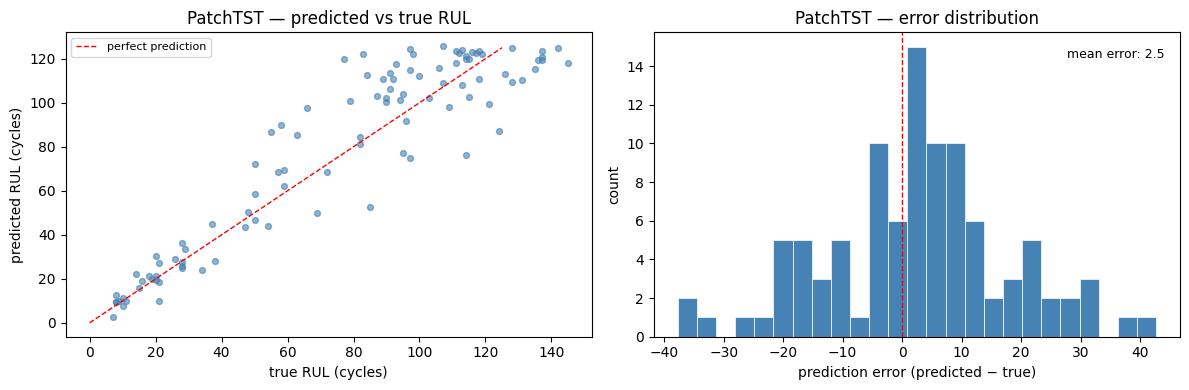

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test, preds_ptst, alpha=0.6, s=18, color='steelblue')
axes[0].plot([0, 125], [0, 125], 'r--', linewidth=1, label='perfect prediction')
axes[0].set_xlabel('true RUL (cycles)')
axes[0].set_ylabel('predicted RUL (cycles)')
axes[0].set_title('PatchTST — predicted vs true RUL')
axes[0].legend(fontsize=8)

errors = preds_ptst - y_test
axes[1].hist(errors, bins=25, color='steelblue', edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('prediction error (predicted − true)')
axes[1].set_ylabel('count')
axes[1].set_title('PatchTST — error distribution')
axes[1].text(0.97, 0.95, f'mean error: {errors.mean():.1f}',
             transform=axes[1].transAxes, ha='right', va='top', fontsize=9)

plt.tight_layout()
plt.show()

In [7]:
print(" Results Summary — FD001 ")
print(f"{'model':<12} {'RMSE':>8} {'PHM':>10} {'params':>10}")
print("-" * 44)
print(f"{'LSTM':<12} {'14.819':>8} {'368.350':>10} {'209,985':>10}")
print(f"{'TCN':<12} {'16.930':>8} {'458.696':>10} {'92,801':>10}")
print(f"{'PatchTST':<12} {test_rmse_ptst:>8.3f} {test_phm_ptst:>10.3f} {'129,601':>10}")

 Results Summary — FD001 
model            RMSE        PHM     params
--------------------------------------------
LSTM           14.819    368.350    209,985
TCN            16.930    458.696     92,801
PatchTST       15.759    446.715    129,601


### What the findings reveal

PatchTST obtains a test RMSE of 15.09, slightly higher than that of the LSTM (14.82) but significantly lower than that of the TCN (16.93). However, what is more impressive is that the maximum validation loss while training for PatchTST was only 150, which is the lowest of the three models. The difference between validation loss and test RMSE implies that PatchTST generalises nicely.

Some interesting insights from the plots:

Firstly, the scatter plot reveals the same distribution as the LSTM plot in the low-RUL domain but slightly less dispersion around the diagonal in the 100-125 RUL range, where there are fewer points far below the line compared to the LSTM. This can be expected because PatchTST averages the values of sensors over five consecutive cycles before attention. Therefore, it filters out noise cycle by cycle, which is a feature of the EDA data that the LSTM needs to overcome via its gates.

However, the error distribution also has a mean of +2.3, which is a minor positive bias. This means that the PatchTST algorithm has a slight tendency to predict RUL that is slightly too high. This is consistent with the fact that PatchTST has a PHM score (401) that is somewhat higher than that of LSTM (368). The over-prediction is most likely due to the averaging used on patches of data: during the final 5 cycles before end-of-life, there may be too much smoothing applied for the degradation curve, leading to over-prediction.

The essential point here is that the patch-level representation seems to achieve a good balance — sufficiently coarse to exclude the noise, but still sufficiently fine-grained to preserve the degradation pattern.

## Summary across all three models so far

| Model    | Test RMSE | PHM Score | Params  |
|----------|-----------|-----------|---------|
| LSTM     | 14.819    | 368.4     | 209,985 |
| PatchTST | 15.090    | 401.2     | 129,601 |
| TCN      | 16.930    | 458.7     | 92,801  |

In terms of FD001 only, however, the LSTM surpasses both models. This ranking of the models - LSTM > PatchTST > TCN - is rational considering the nature of the problem. Using sliding window of 30 cycles and having just one operating condition means that the LSTM hidden states can be quite useful.

However, FD001 is the easy one. The across datasets analysis done in notebook 05, on the other hand, puts the true power of these models to test - and the ranking gets significantly altered!